# Introduction

In the e-commerce and marketplace industry, acquiring a new customer is only the first step. Long-term profitability and sustainable growth are heavily dependent on **customer retention**.

The purpose of this notebook is to perform a **Time-Based Cohort Analysis** to evaluate user loyalty and track retention patterns over time. By grouping customers into cohorts based on the month of their first purchase, we can observe how their purchasing behavior changes in subsequent months.

## Import Statements and setting style

In [1]:
import pandas as pd
import seaborn as sns
import src.plotting as plot

In [2]:
pd.options.display.float_format = "{:,.2f}".format

plot.set_plot_style()

# Data Load

In [3]:
from src.helpers import load_view

df_cohort = load_view("vw_customer_monthly_activity")

In [4]:
df_cohort["cohort_month"] = pd.to_datetime(df_cohort["cohort_month"]).dt.to_period("M")
df_cohort["purchase_month"] = pd.to_datetime(df_cohort["purchase_month"]).dt.to_period("M")

In [5]:
df_cohort = df_cohort[df_cohort["cohort_month"] >= "2017-01-01"]

Note: Cohorts from the end of 2016 are non-representative due to insufficient sample size during this timeframe. The primary analysis should focus on cohorts starting from 2017-01.

# Customer Cohort Analysis

In [6]:
c_cohort_matrix = df_cohort.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id",
    aggfunc="nunique"
)

In [7]:
cohort_sizes = c_cohort_matrix.iloc[:, 0]
retention_matrix = c_cohort_matrix.divide(cohort_sizes, axis=0).round(3)
retention_plot = retention_matrix.iloc[:, 1:]

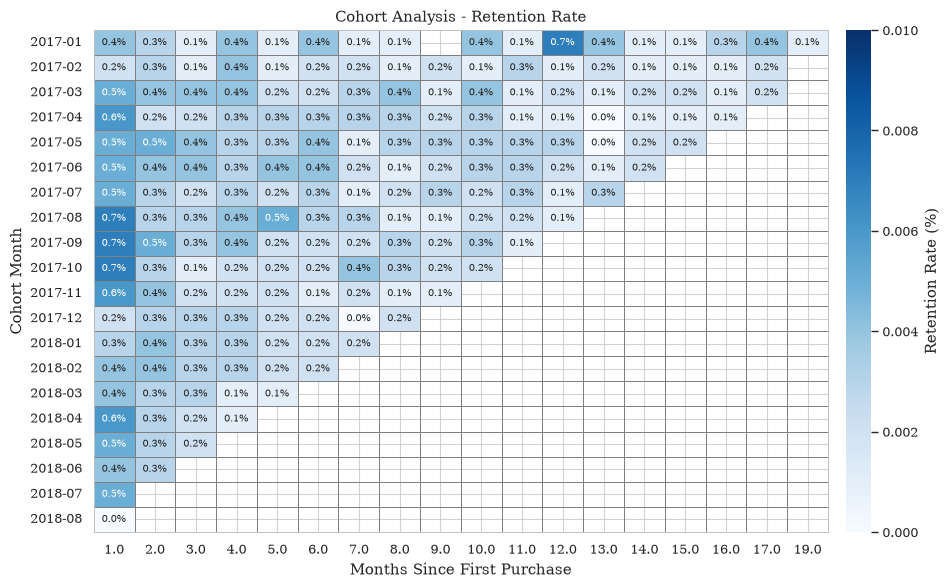

In [8]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.heatmap(
    data=retention_plot,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmax=0.01,
    linewidths=0.7,
    linecolor="gray",
    cbar_kws={"label": "Retention Rate (%)", "pad": 0.02},
    annot_kws={"fontsize": 7},
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color("silver")
    spine.set_linewidth(0.7)

plot.finish_plot(
    ax1=ax1,
    title="Cohort Analysis - Retention Rate",
    xlabel="Months Since First Purchase",
    ax1_ylabel="Cohort Month",
    legend=False
)

# Revenue Cohort Analysis

In [9]:
r_cohort_matrix = df_cohort.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="revenue_in_month",
    aggfunc="sum"
)

In [10]:
cohort_revenue_sizes = r_cohort_matrix.iloc[:, 0]
revenue_retention_matrix = r_cohort_matrix.divide(cohort_revenue_sizes, axis=0).round(3)
revenue_retention_plot = revenue_retention_matrix.iloc[:, 1:]

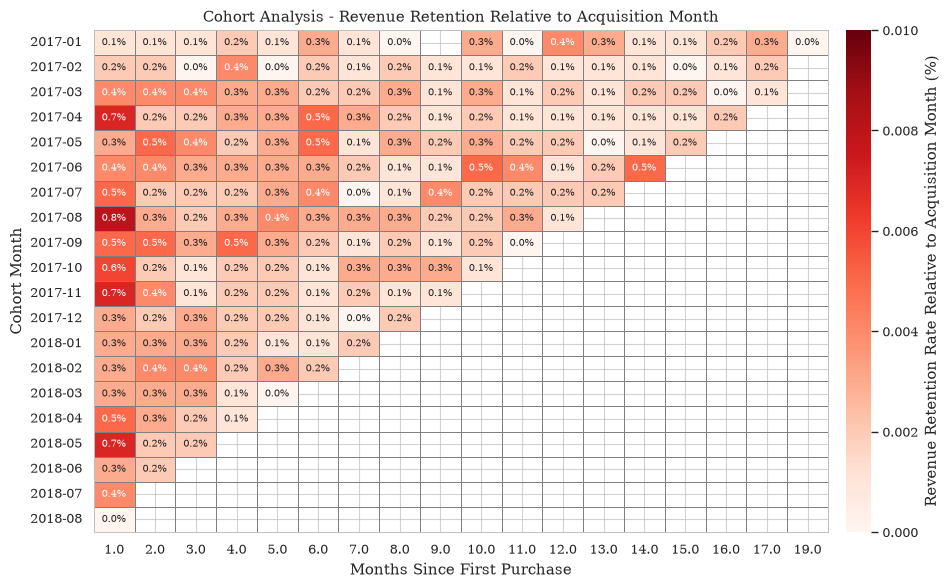

In [11]:
fig, ax1 = plot.create_figure(rotate_x=False, sec_y=False)

sns.heatmap(
    data=revenue_retention_plot,
    annot=True,
    fmt=".1%",
    cmap="Reds",
    vmax=0.01,
    linewidths=0.7,
    linecolor="gray",
    cbar_kws={"label": "Revenue Retention Rate Relative to Acquisition Month (%)", "pad": 0.02},
    annot_kws={"fontsize": 7},
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color("silver")
    spine.set_linewidth(0.7)

plot.finish_plot(
    ax1=ax1,
    title="Cohort Analysis - Revenue Retention Relative to Acquisition Month",
    xlabel="Months Since First Purchase",
    ax1_ylabel="Cohort Month",
    legend=False
)

# Cohort Size Distribution

In [12]:
cohort_sizes.loc["2017-01":].to_frame("cohort_size")

,cohort_size
cohort_month,
2017-01,752.00
2017-02,"1,690.00"
2017-03,"2,571.00"
2017-04,"2,325.00"
2017-05,"3,541.00"
2017-06,"3,102.00"
2017-07,"3,822.00"
2017-08,"4,130.00"
2017-09,"4,075.00"


Cohort sizes vary considerably, especially at the beginning of 2017, so small differences between monthly retention rates should be interpreted cautiously.

# Summary

<b>Business Model</b>: The cohort results are consistent with a predominantly one-time purchase pattern, with very few customers returning in subsequent months.

<b>Loyalty</b>: Overall customer retention remains very low throughout the observed period. The vast majority of users make a single purchase and never return to the platform.

<b>Baseline</b>: The very small percentage of customers who do return tend to remain active at a stable, low rate (0.1% to 0.4%) for 12 or more months. Revenue retention occasionally exceeds customer retention, suggesting that the small group of returning customers may generate above-average order value. This would require customer-level spending analysis to verify.

<b>Recommendations</b>: The business could consider introducing welcome offers, retargeting ads, or loyalty programs immediately after the first purchase to encourage a second order. Investigate whether marketing campaigns, seasonality, or changes in the customer mix contributed to the slightly higher Month 1 retention observed in selected 2017 cohorts.